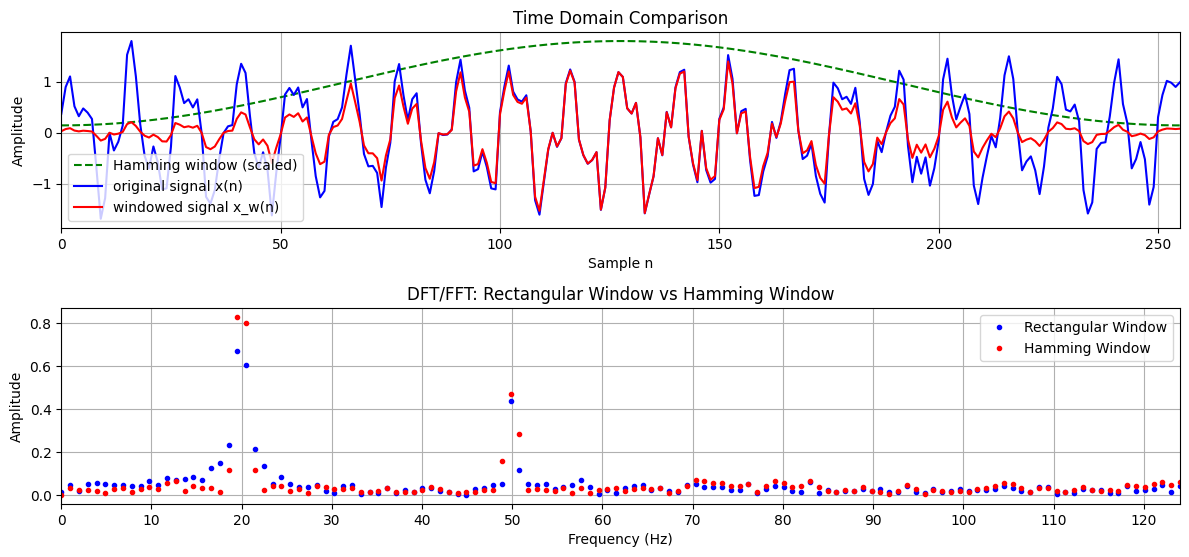

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 构造原始信号
fs = 250                          # 采样率
N = 256                            # 窗口长度
n = np.arange(N)

# 模拟信号：两个正弦波 + 噪声
x = np.sin(2*np.pi*20*n/fs) + 0.5*np.sin(2*np.pi*50*n/fs) + 0.2*np.random.randn(N)

# 添加Hamming窗
# w = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1)) 
w = np.hamming(N)    
x_windowed = x * w

# 计算FFT
X_rect   = np.abs(np.fft.fft(x))           # 不加窗（矩形窗）
X_hamm   = np.abs(np.fft.fft(x_windowed))  # 加Hamming 窗

# 修正
X_rect = X_rect / N                       # 矩形窗需要除以N
X_hamm = X_hamm / np.sum(w)              # Hamming窗需要除以窗函数的和

# 单边
X_rect_single = X_rect.copy()
X_rect_single[1:] *= 2          # 单边谱需要乘以2   
X_hamm_single = X_hamm.copy()
X_hamm_single[1:] *= 2          # 单边谱需要乘以2   




plt.figure(figsize=(12, 8))
# 子图1：原始信号 vs 加窗信号
plt.subplot(3, 1, 1)
# 绘制Hamming窗
plt.plot(n, w * np.max(np.abs(x)), 'g--', label='Hamming window (scaled)')
plt.plot(n, x, 'b-', label='original signal x(n)')
plt.plot(n, x_windowed, 'r-', label='windowed signal x_w(n)')
plt.legend()
plt.title('Time Domain Comparison')
plt.ylabel('Amplitude')
plt.xlabel('Sample n')
# 添加网格
plt.grid(True)
# 设置y轴刻度间隔
plt.xlim(0, N-1)




"""
[   0.           0.9765625    1.953125     2.9296875    3.90625
    4.8828125    5.859375     6.8359375    7.8125       8.7890625
    9.765625    10.7421875   11.71875     12.6953125   13.671875
   14.6484375   15.625       16.6015625   17.578125    18.5546875
   19.53125     20.5078125   21.484375    22.4609375   23.4375
   24.4140625   25.390625    26.3671875   27.34375     28.3203125
   29.296875    30.2734375   31.25        32.2265625   33.203125
   34.1796875   35.15625     36.1328125   37.109375    38.0859375
   39.0625      40.0390625   41.015625    41.9921875   42.96875
   43.9453125   44.921875    45.8984375   46.875       47.8515625
   48.828125    49.8046875   50.78125     51.7578125   52.734375
   53.7109375   54.6875      55.6640625   56.640625    57.6171875
   58.59375     59.5703125   60.546875    61.5234375   62.5
   63.4765625   64.453125    65.4296875   66.40625     67.3828125
   68.359375    69.3359375   70.3125      71.2890625   72.265625
   73.2421875   74.21875     75.1953125   76.171875    77.1484375
   78.125       79.1015625   80.078125    81.0546875   82.03125
   83.0078125   83.984375    84.9609375   85.9375      86.9140625
   87.890625    88.8671875   89.84375     90.8203125   91.796875
   92.7734375   93.75        94.7265625   95.703125    96.6796875
   97.65625     98.6328125   99.609375   100.5859375  101.5625
  102.5390625  103.515625   104.4921875  105.46875    106.4453125
  107.421875   108.3984375  109.375      110.3515625  111.328125
  112.3046875  113.28125    114.2578125  115.234375   116.2109375
  117.1875     118.1640625  119.140625   120.1171875  121.09375
  122.0703125  123.046875   124.0234375 -125.        -124.0234375
 -123.046875  -122.0703125 -121.09375   -120.1171875 -119.140625
 -118.1640625 -117.1875    -116.2109375 -115.234375  -114.2578125
 -113.28125   -112.3046875 -111.328125  -110.3515625 -109.375
 -108.3984375 -107.421875  -106.4453125 -105.46875   -104.4921875
 -103.515625  -102.5390625 -101.5625    -100.5859375  -99.609375
  -98.6328125  -97.65625    -96.6796875  -95.703125   -94.7265625
  -93.75       -92.7734375  -91.796875   -90.8203125  -89.84375
  -88.8671875  -87.890625   -86.9140625  -85.9375     -84.9609375
  -83.984375   -83.0078125  -82.03125    -81.0546875  -80.078125
  -79.1015625  -78.125      -77.1484375  -76.171875   -75.1953125
  -74.21875    -73.2421875  -72.265625   -71.2890625  -70.3125
  -69.3359375  -68.359375   -67.3828125  -66.40625    -65.4296875
  -64.453125   -63.4765625  -62.5        -61.5234375  -60.546875
  -59.5703125  -58.59375    -57.6171875  -56.640625   -55.6640625
  -54.6875     -53.7109375  -52.734375   -51.7578125  -50.78125
  -49.8046875  -48.828125   -47.8515625  -46.875      -45.8984375
  -44.921875   -43.9453125  -42.96875    -41.9921875  -41.015625
  -40.0390625  -39.0625     -38.0859375  -37.109375   -36.1328125
  -35.15625    -34.1796875  -33.203125   -32.2265625  -31.25
  -30.2734375  -29.296875   -28.3203125  -27.34375    -26.3671875
  -25.390625   -24.4140625  -23.4375     -22.4609375  -21.484375
  -20.5078125  -19.53125    -18.5546875  -17.578125   -16.6015625
  -15.625      -14.6484375  -13.671875   -12.6953125  -11.71875
  -10.7421875   -9.765625    -8.7890625   -7.8125      -6.8359375
   -5.859375    -4.8828125   -3.90625     -2.9296875   -1.953125
   -0.9765625]
"""
# 给长度为 N 的 FFT 结果，生成每个 bin 对应的频率坐标。
freqs = np.fft.fftfreq(N, d=1/fs)   
half = N // 2 # 128


# 子图2：矩形窗频谱
plt.subplot(3, 1, 2)
plt.plot(freqs[:half], X_rect_single[:half], 'b.',label='Rectangular Window')
plt.plot(freqs[:half], X_hamm_single[:half],'r.',label='Hamming Window')
plt.title('DFT/FFT: Rectangular Window vs Hamming Window')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend()
# 添加网格
plt.grid(True)
# x轴显示最后一个坐标
plt.xlim(0, freqs[half-1])
# 设置y轴刻度间隔

plt.xticks(np.arange(0, freqs[half-1], 10))

plt.tight_layout()
# plt.show()


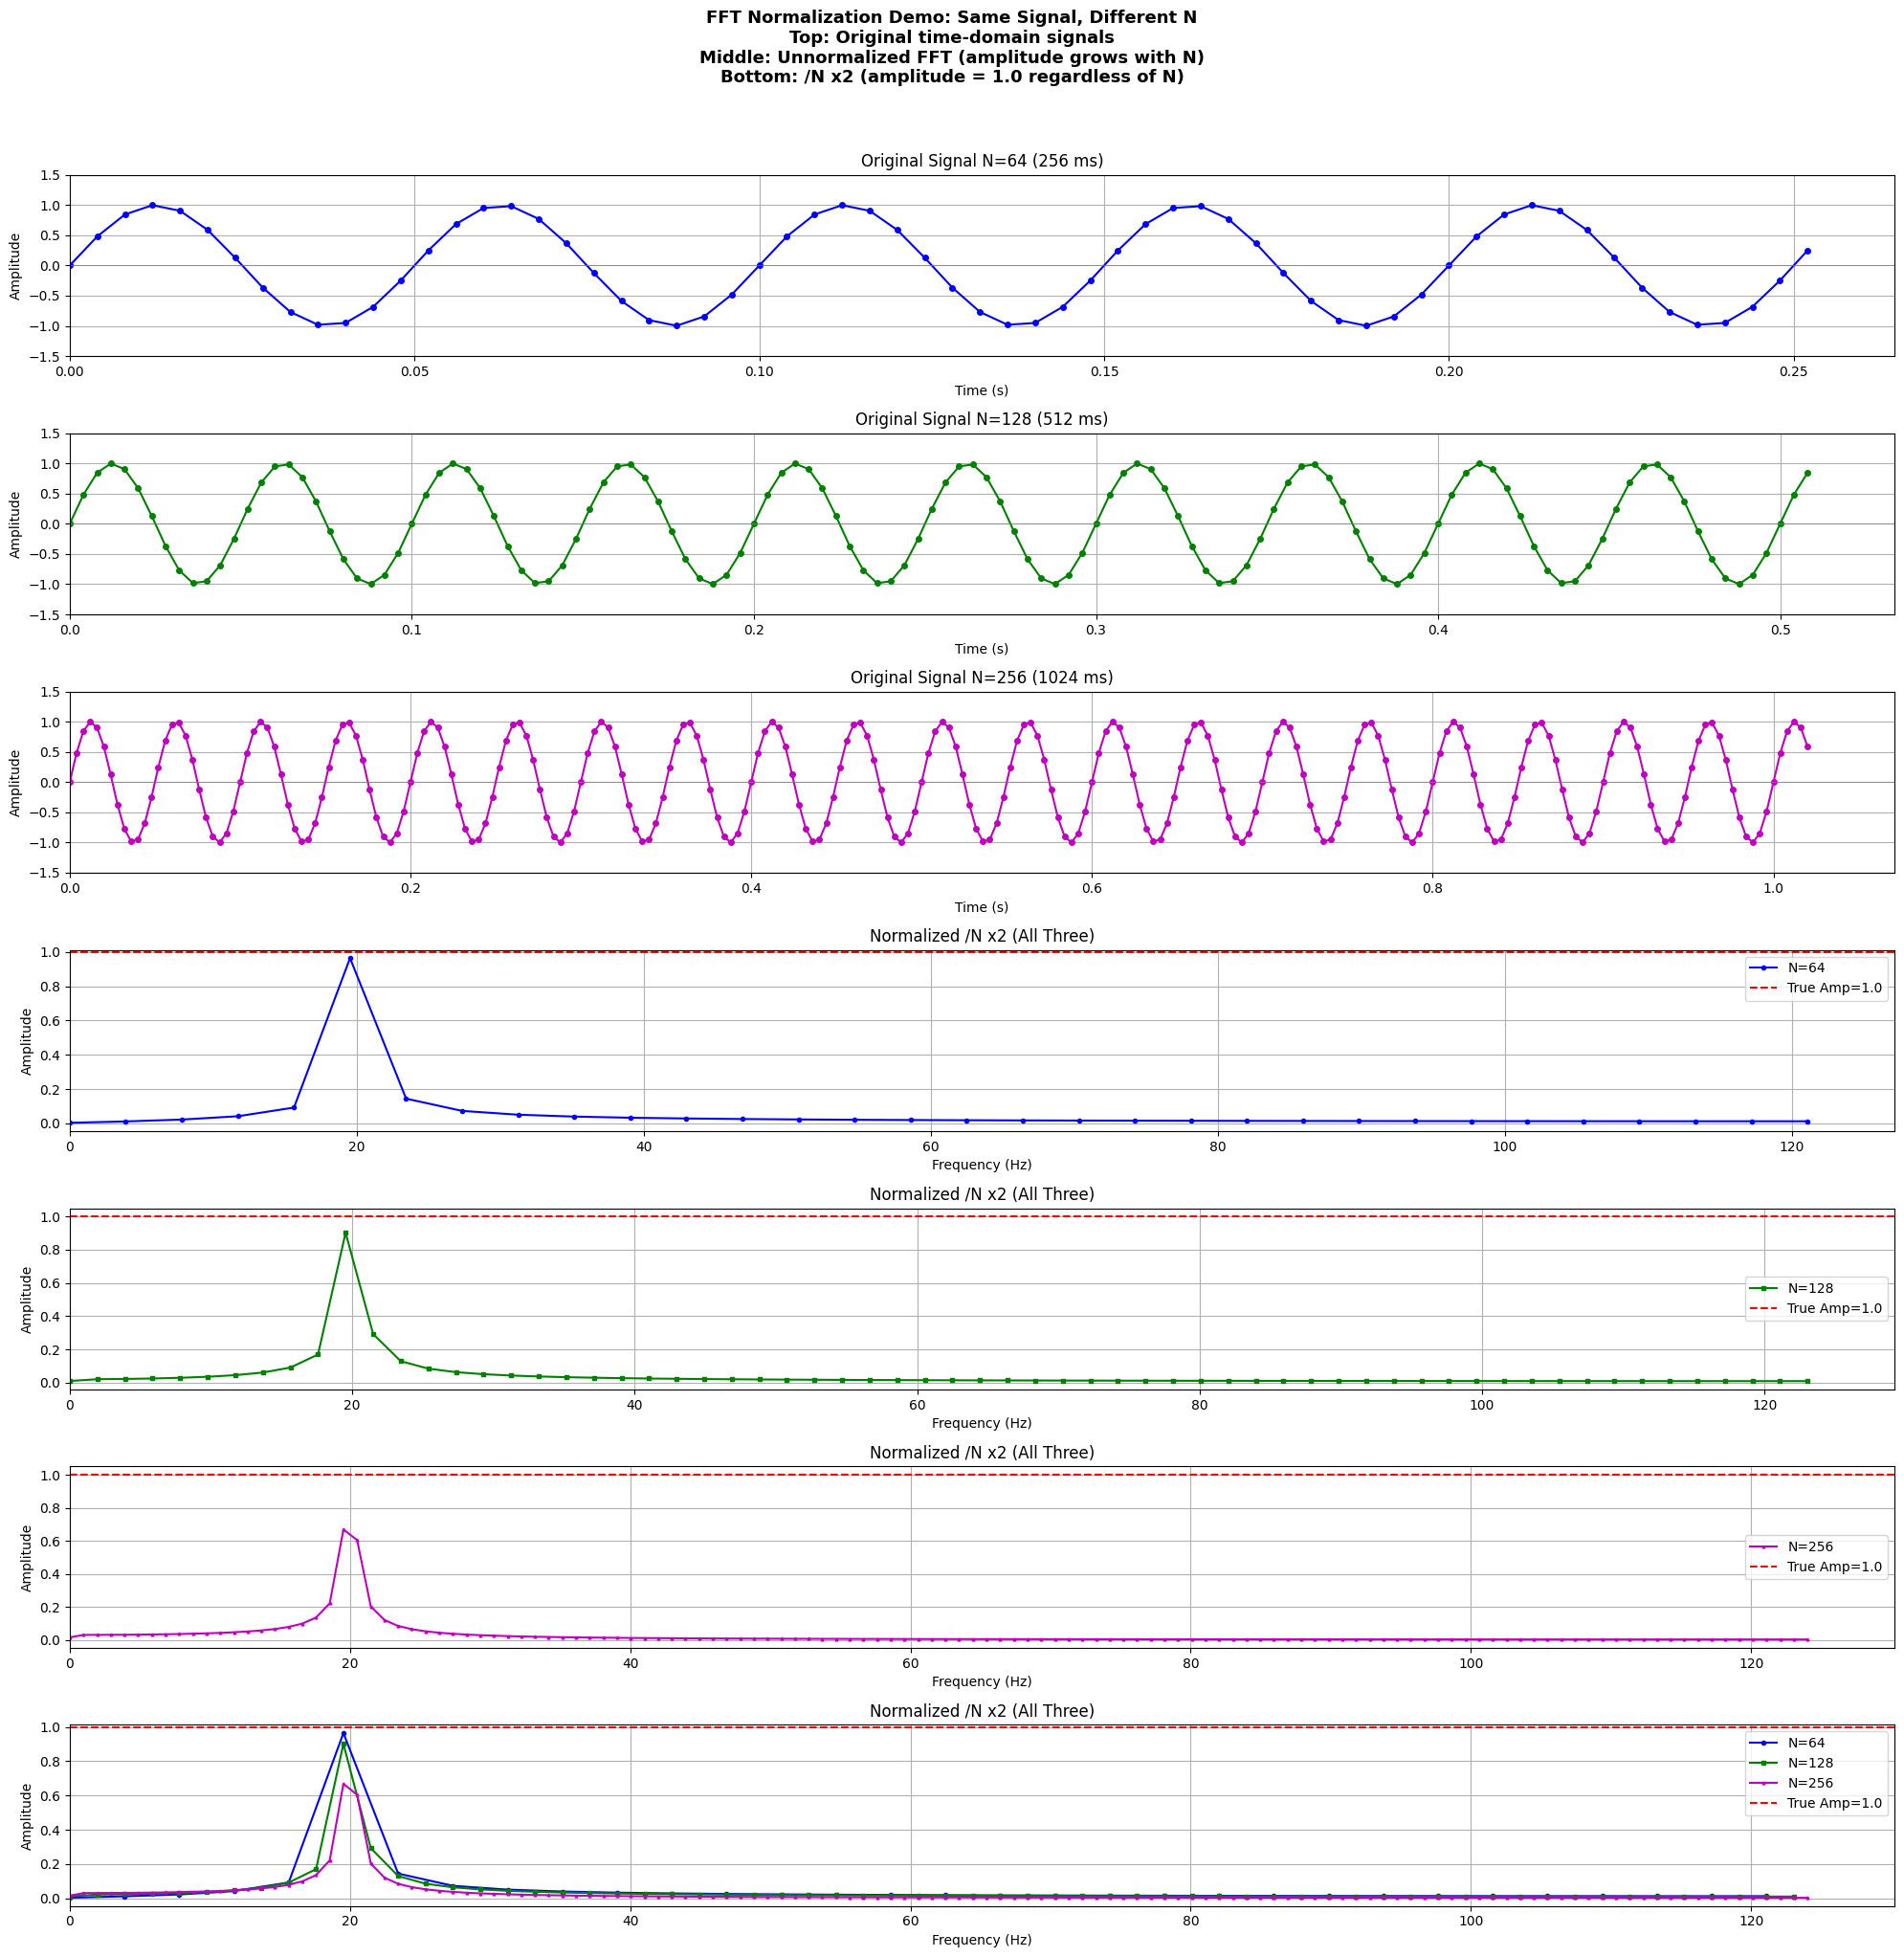

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Demo: FFT amplitude vs signal length N
# ============================================

fs = 250  # 采样率

N1 = 64
n1 = np.arange(N1)
x1 = np.sin(2 * np.pi * 20 * n1 / fs)
X1 = np.abs(np.fft.fft(x1))
X1_fixed = X1 / N1          # 双边谱
X1_single = X1_fixed.copy() # 单边谱
X1_single[1:] *= 2          # 单边谱需要乘以2


N2 = 128
n2 = np.arange(N2)
x2 = np.sin(2 * np.pi * 20 * n2 / fs)
X2 = np.abs(np.fft.fft(x2))
X2_fixed = X2 / N2          # 双边谱
X2_single = X2_fixed.copy() # 单边谱
X2_single[1:] *= 2          # 单边谱需要乘以2   


N3 = 256
n3 = np.arange(N3)
x3 = np.sin(2 * np.pi * 20 * n3 / fs)
X3 = np.abs(np.fft.fft(x3))
X3_fixed = X3 / N3          # 双边谱
X3_single = X3_fixed.copy() # 单边谱
X3_single[1:] *= 2          # 单边谱需要乘以2   



# ============================================
# Plot comparison
# ============================================
fig, axes = plt.subplots(7, 1, figsize=(20, 20))


t1 = n1 / fs
t2 = n2 / fs
t3 = n3 / fs

axes[0].plot(t1, x1, 'b-o', markersize=4)
axes[0].set_title(f'Original Signal N={N1} ({N1/fs*1000:.0f} ms)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.5, 1.5)
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[0].grid(True)
axes[0].set_xlim(0)



axes[1].plot(t2, x2, 'g-o', markersize=4)
axes[1].set_title(f'Original Signal N={N2} ({N2/fs*1000:.0f} ms)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim(-1.5, 1.5)
axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[1].grid(True)
axes[1].set_xlim(0)



axes[2].plot(t3, x3, 'm-o', markersize=4)
axes[2].set_title(f'Original Signal N={N3} ({N3/fs*1000:.0f} ms)')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Amplitude') 
axes[2].set_ylim(-1.5, 1.5)
axes[2].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[2].grid(True)
axes[2].set_xlim(0)



# bin 频率
freqs1 = np.fft.fftfreq(N1, d=1/fs)
freqs2 = np.fft.fftfreq(N2, d=1/fs)
freqs3 = np.fft.fftfreq(N3, d=1/fs)
half1 = N1 // 2
half2 = N2 // 2
half3 = N3 // 2


axes[3].plot(freqs1[:half1], X1_single[:half1], 'b-o', markersize=3, label=f'N={N1}')
axes[3].set_title('Normalized /N x2 (All Three)')
axes[3].set_xlabel('Frequency (Hz)')
axes[3].set_ylabel('Amplitude')
axes[3].axhline(y=1.0, color='r', linestyle='--', label='True Amp=1.0')
axes[3].legend()
axes[3].grid(True)
axes[3].set_xlim(0)

axes[4].plot(freqs2[:half2], X2_single[:half2], 'g-s', markersize=3, label=f'N={N2}')
axes[4].set_title('Normalized /N x2 (All Three)')
axes[4].set_xlabel('Frequency (Hz)')
axes[4].set_ylabel('Amplitude')
axes[4].axhline(y=1.0, color='r', linestyle='--', label='True Amp=1.0')
axes[4].legend()
axes[4].grid(True)
axes[4].set_xlim(0)

axes[5].plot(freqs3[:half3], X3_single[:half3], 'm-^', markersize=2, label=f'N={N3}')
axes[5].set_title('Normalized /N x2 (All Three)')
axes[5].set_xlabel('Frequency (Hz)')
axes[5].set_ylabel('Amplitude')
axes[5].axhline(y=1.0, color='r', linestyle='--', label='True Amp=1.0')
axes[5].legend()
axes[5].grid(True)
axes[5].set_xlim(0)



axes[6].plot(freqs1[:half1], X1_single[:half1], 'b-o', markersize=3, label=f'N={N1}')
axes[6].plot(freqs2[:half2], X2_single[:half2], 'g-s', markersize=3, label=f'N={N2}')
axes[6].plot(freqs3[:half3], X3_single[:half3], 'm-^', markersize=2, label=f'N={N3}')
axes[6].set_title('Normalized /N x2 (All Three)')
axes[6].set_xlabel('Frequency (Hz)')
axes[6].set_ylabel('Amplitude')
axes[6].axhline(y=1.0, color='r', linestyle='--', label='True Amp=1.0')
axes[6].legend()
axes[6].grid(True)
axes[6].set_xlim(0)



plt.suptitle('FFT Normalization Demo: Same Signal, Different N\n'
             'Top: Original time-domain signals\n'
             'Middle: Unnormalized FFT (amplitude grows with N)\n'
             'Bottom: /N x2 (amplitude = 1.0 regardless of N)',
             fontsize=13, fontweight='bold',y = 1.02)
plt.tight_layout()
# plt.show()


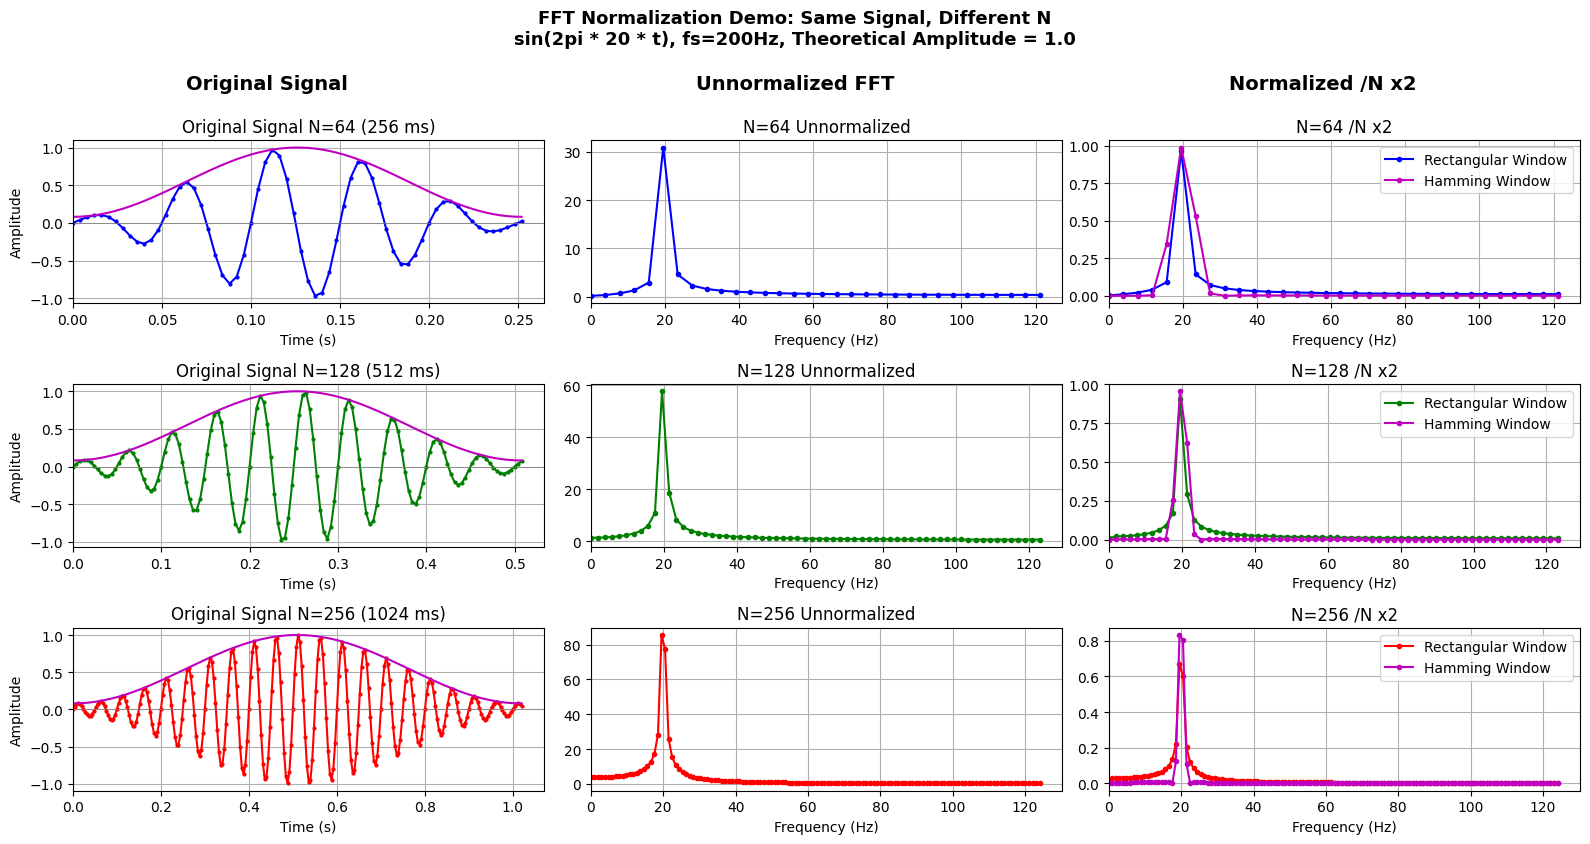

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Demo: FFT amplitude vs signal length N
# ============================================

fs = 250  # 采样率

N1 = 64
n1 = np.arange(N1)
x1 = np.sin(2 * np.pi * 20 * n1 / fs)
X1 = np.abs(np.fft.fft(x1))
X1_fixed = X1 / N1 # 矩形窗需要除以N
X1_single = X1_fixed.copy()
X1_single[1:] *= 2
# 添加Hamming窗
w = np.hamming(N1)
x1_windowed = x1 * w
X1_windowed = np.abs(np.fft.fft(x1_windowed))
X1_windowed_fixed = X1_windowed / np.sum(w) # Hamming窗需要除以窗函数的和
X1_windowed_single = X1_windowed_fixed.copy()
X1_windowed_single[1:] *= 2




N2 = 128
n2 = np.arange(N2)
x2 = np.sin(2 * np.pi * 20 * n2 / fs)
X2 = np.abs(np.fft.fft(x2))
X2_fixed = X2 / N2 # 矩形窗需要除以N
X2_single = X2_fixed.copy()
X2_single[1:] *= 2
# 添加Hamming窗
w = np.hamming(N2)
x2_windowed = x2 * w
X2_windowed = np.abs(np.fft.fft(x2_windowed))
X2_windowed_fixed = X2_windowed / np.sum(w) # Hamming窗需要除以窗函数的和
X2_windowed_single = X2_windowed_fixed.copy()
X2_windowed_single[1:] *= 2


N3 = 256
n3 = np.arange(N3)
x3 = np.sin(2 * np.pi * 20 * n3 / fs)
X3 = np.abs(np.fft.fft(x3))
X3_fixed = X3 / N3 # 矩形窗需要除以N    
X3_single = X3_fixed.copy()
X3_single[1:] *= 2
# 添加Hamming窗
w = np.hamming(N3)
x3_windowed = x3 * w
X3_windowed = np.abs(np.fft.fft(x3_windowed))
X3_windowed_fixed = X3_windowed / np.sum(w) # Hamming窗需要除以窗函数的和
X3_windowed_single = X3_windowed_fixed.copy()
X3_windowed_single[1:] *= 2



# ============================================
# Plot: 3 rows x 3 columns
# Column 1: Original signal
# Column 2: Unnormalized FFT
# Column 3: Normalized FFT (/N x2)
# ============================================
fig, axes = plt.subplots(3, 3, figsize=(16, 8))

signals = [
    (N1, n1, x1_windowed, X1, X1_single,X1_windowed_single,'b'),
    (N2, n2, x2_windowed, X2, X2_single,X2_windowed_single,'g'),
    (N3, n3, x3_windowed, X3, X3_single,X3_windowed_single,'r'),
]

for i, (N, n, x, X_unnorm, X_norm,X_windowed_norm, color) in enumerate(signals):
    t = n / fs
    freqs = np.fft.fftfreq(N, d=1/fs)
    half = N // 2
    duration_ms = N / fs * 1000

    # --- Column 1: Original signal ---
    axes[i, 0].plot(t, x, f'{color}-o', markersize=2)
    axes[i, 0].plot(t, np.hamming(N), f'm', markersize=2)
    axes[i, 0].set_title(f'Original Signal N={N} ({duration_ms:.0f} ms)')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    axes[i, 0].grid(True)
    axes[i, 0].set_xlim(0)

    # --- Column 2: Unnormalized FFT ---
    axes[i, 1].plot(freqs[:half], X_unnorm[:half], f'{color}-o', markersize=3)
    axes[i, 1].set_title(f'N={N} Unnormalized')
    axes[i, 1].set_xlabel('Frequency (Hz)')
    axes[i, 1].grid(True)
    axes[i, 1].set_xlim(0)

    # --- Column 3: Normalized FFT (/N x2) ---
    axes[i, 2].plot(freqs[:half], X_norm[:half], f'{color}-o', label='Rectangular Window', markersize=3)
    axes[i, 2].plot(freqs[:half], X_windowed_norm[:half], f'm-o', label='Hamming Window', markersize=3)
    axes[i, 2].set_title(f'N={N} /N x2')
    axes[i, 2].set_xlabel('Frequency (Hz)')
    axes[i, 2].grid(True)
    axes[i, 2].legend()
    axes[i, 2].set_xlim(0)

# Column headers
fig.text(0.17, 0.95, 'Original Signal', ha='center', fontsize=14, fontweight='bold')
fig.text(0.50, 0.95, 'Unnormalized FFT', ha='center', fontsize=14, fontweight='bold')
fig.text(0.83, 0.95, 'Normalized /N x2', ha='center', fontsize=14, fontweight='bold')

plt.suptitle('FFT Normalization Demo: Same Signal, Different N\n'
             'sin(2pi * 20 * t), fs=200Hz, Theoretical Amplitude = 1.0',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
# plt.show()


True Amplitude = 1.0
Raw FFT (N=64):                        0.9648
Bin-aligned N (N=100):                 1.0000
Zero-padding + Parabolic Interpolation:      0.9793
Hann Window + Correction:                    0.9910
Goertzel (integer k):                        0.9648
Goertzel (non-integer k):                    0.9785


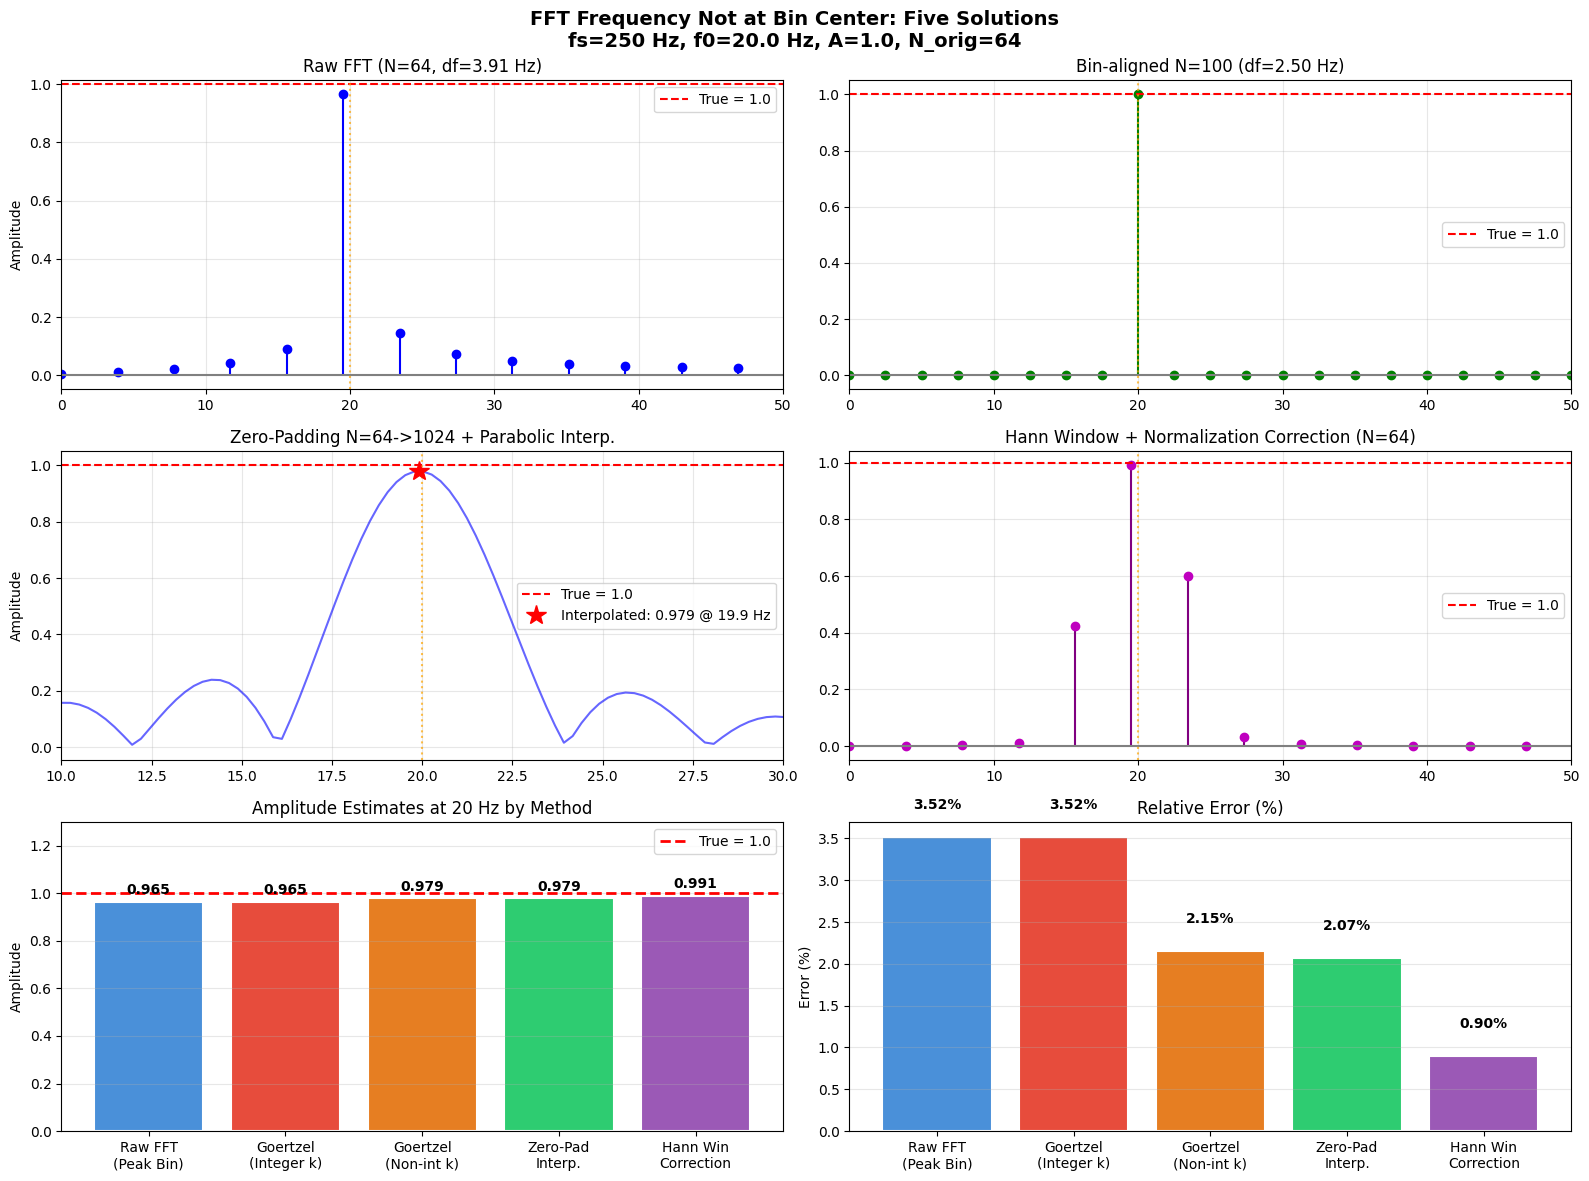

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

# ============================================
# 基础参数
# ============================================
fs = 250
f0 = 20.0
A_true = 1.0
N_orig = 64

n = np.arange(N_orig)
x = A_true * np.sin(2 * np.pi * f0 * n / fs)

# ============================================
# 方法 0: 原始 FFT (作为对照)
# ============================================
X_raw = np.fft.fft(x)
freqs_raw = np.fft.fftfreq(N_orig, d=1/fs)
amp_raw = np.abs(X_raw) / N_orig * 2  # 单边谱

# ============================================
# 方法 1: 选 N 使频率正好落在 bin 上
# ============================================
# 要求 f0 = k * fs / N, 即 N = k * fs / f0
# fs=250, f=20 → N = k * 250/20 = k * 12.5
# N = 50, 100, 150... 都可以让 20Hz 正好在 bin 上

N_exact = 100  # Δf = 2.5 Hz, bin 8 = 20 Hz ✓
n_exact = np.arange(N_exact)
x_exact = A_true * np.sin(2 * np.pi * f0 * n_exact / fs)
X_exact = np.fft.fft(x_exact)
freqs_exact = np.fft.fftfreq(N_exact, d=1/fs)
amp_exact = np.abs(X_exact) / N_exact * 2

# ============================================
# 方法 2: 零填充 + 插值
# ============================================
N_zp = N_orig * 16  # 补零到 1024 点
x_zp = np.zeros(N_zp)
x_zp[:N_orig] = x

X_zp = np.fft.fft(x_zp)
freqs_zp = np.fft.fftfreq(N_zp, d=1/fs)
amp_zp = np.abs(X_zp) / N_orig * 2  # 注意除以原始 N

# 抛物线插值找峰值
half = N_zp // 2
idx_peak = np.argmax(amp_zp[:half])

# 用峰值及其左右两个点做抛物线插值
if idx_peak > 0 and idx_peak < half - 1:
    alpha = amp_zp[idx_peak - 1]
    beta  = amp_zp[idx_peak]
    gamma = amp_zp[idx_peak + 1]
    p = 0.5 * (alpha - gamma) / (alpha - 2*beta + gamma)
    amp_interp = beta - 0.25 * (alpha - gamma) * p
    freq_interp = freqs_zp[idx_peak] + p * (freqs_zp[1] - freqs_zp[0])
else:
    amp_interp = amp_zp[idx_peak]
    freq_interp = freqs_zp[idx_peak]

# ============================================
# 方法 3: 加窗 (Hann 窗) + 修正
# ============================================
# Hann 窗的相干增益 = 0.5, 所以幅值要乘以 2 修正
win = np.hanning(N_orig)
x_win = x * win
X_win = np.fft.fft(x_win)
amp_win = np.abs(X_win) / np.sum(win) * 2  # 除以窗的和再 ×2

# ============================================
# 方法 4: Goertzel 算法 — 直接算指定频率
# ============================================
def goertzel(x, fs, f_target):
    """
    Goertzel 算法: 直接计算信号在 f_target 处的 DFT 值
    复杂度 O(N), 比 FFT 更适合单频检测
    """
    N = len(x)
    k = int(round(N * f_target / fs))
    w = 2 * np.pi * k / N
    coeff = 2 * np.cos(w)

    s0, s1, s2 = 0.0, 0.0, 0.0
    for sample in x:
        s0 = sample + coeff * s1 - s2
        s2 = s1
        s1 = s0

    # 实部和虚部
    real = s1 - s2 * np.cos(w)
    imag = s2 * np.sin(w)

    magnitude = 2 * np.sqrt(real**2 + imag**2) / N
    return magnitude

amp_goertzel = goertzel(x, fs, f0)

# ============================================
# 方法 4 改进: 非整数 k 的 Goertzel
# ============================================
def goertzel_noninteger_k(x, fs, f_target):
    """
    用非整数 k 的 Goertzel, 不需要 k 为整数
    """
    N = len(x)
    k = N * f_target / fs  # 不取整！
    w = 2 * np.pi * k / N
    coeff = 2 * np.cos(w)

    s1, s2 = 0.0, 0.0
    for sample in x:
        s0 = sample + coeff * s1 - s2
        s2 = s1
        s1 = s0

    real = s1 - s2 * np.cos(w)
    imag = s2 * np.sin(w)
    magnitude = 2 * np.sqrt(real**2 + imag**2) / N
    return magnitude

amp_goertzel_exact = goertzel_noninteger_k(x, fs, f0)

# ============================================
# 汇总结果
# ============================================
print("=" * 55)
print(f"True Amplitude = {A_true}")
print("=" * 55)
print(f"Raw FFT (N={N_orig}):                        {amp_raw[np.argmax(amp_raw[:N_orig//2])]:.4f}")
print(f"Bin-aligned N (N={N_exact}):                 {amp_exact[np.argmax(amp_exact[:N_exact//2])]:.4f}")
print(f"Zero-padding + Parabolic Interpolation:      {amp_interp:.4f}")
print(f"Hann Window + Correction:                    {np.max(amp_win[:N_orig//2]):.4f}")
print(f"Goertzel (integer k):                        {amp_goertzel:.4f}")
print(f"Goertzel (non-integer k):                    {amp_goertzel_exact:.4f}")

# ============================================
# 可视化
# ============================================
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

half_raw = N_orig // 2
half_exact = N_exact // 2
half_zp = N_zp // 2

# --- (0,0) 原始 FFT ---
ax = axes[0, 0]
ax.stem(freqs_raw[:half_raw], amp_raw[:half_raw], linefmt='b-', markerfmt='bo', basefmt='gray')
ax.axhline(y=A_true, color='r', ls='--', label=f'True = {A_true}')
ax.axvline(x=f0, color='orange', ls=':', alpha=0.7)
ax.set_title(f'Raw FFT (N={N_orig}, df={fs/N_orig:.2f} Hz)')
ax.set_xlim(0, 50)
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# --- (0,1) 选 N 对齐 bin ---
ax = axes[0, 1]
ax.stem(freqs_exact[:half_exact], amp_exact[:half_exact], linefmt='g-', markerfmt='go', basefmt='gray')
ax.axhline(y=A_true, color='r', ls='--', label=f'True = {A_true}')
ax.axvline(x=f0, color='orange', ls=':', alpha=0.7)
ax.set_title(f'Bin-aligned N={N_exact} (df={fs/N_exact:.2f} Hz)')
ax.set_xlim(0, 50)
ax.legend()
ax.grid(True, alpha=0.3)

# --- (1,0) 零填充 ---
ax = axes[1, 0]
ax.plot(freqs_zp[:half_zp], amp_zp[:half_zp], 'b-', alpha=0.6)
ax.axhline(y=A_true, color='r', ls='--', label=f'True = {A_true}')
ax.axvline(x=f0, color='orange', ls=':', alpha=0.7)
ax.plot(freq_interp, amp_interp, 'r*', ms=15, label=f'Interpolated: {amp_interp:.3f} @ {freq_interp:.1f} Hz')
ax.set_title(f'Zero-Padding N={N_orig}->{N_zp} + Parabolic Interp.')
ax.set_xlim(10, 30)
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# --- (1,1) 加窗 ---
ax = axes[1, 1]
ax.stem(freqs_raw[:half_raw], amp_win[:half_raw], linefmt='purple', markerfmt='mo', basefmt='gray')
ax.axhline(y=A_true, color='r', ls='--', label=f'True = {A_true}')
ax.axvline(x=f0, color='orange', ls=':', alpha=0.7)
ax.set_title(f'Hann Window + Normalization Correction (N={N_orig})')
ax.set_xlim(0, 50)
ax.legend()
ax.grid(True, alpha=0.3)

# --- (2,0) Goertzel 对比 ---
ax = axes[2, 0]
methods = ['Raw FFT\n(Peak Bin)', 'Goertzel\n(Integer k)', 'Goertzel\n(Non-int k)', 'Zero-Pad\nInterp.', 'Hann Win\nCorrection']
values = [
    amp_raw[np.argmax(amp_raw[:half_raw])],
    amp_goertzel,
    amp_goertzel_exact,
    amp_interp,
    np.max(amp_win[:half_raw])
]
colors = ['#4a90d9', '#e74c3c', '#e67e22', '#2ecc71', '#9b59b6']
bars = ax.bar(methods, values, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(y=A_true, color='r', ls='--', lw=2, label=f'True = {A_true}')
ax.set_ylim(0, 1.3)
ax.set_title('Amplitude Estimates at 20 Hz by Method')
ax.set_ylabel('Amplitude')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# --- (2,1) 误差分析 ---
ax = axes[2, 1]
errors = [abs(v - A_true) / A_true * 100 for v in values]
bars2 = ax.bar(methods, errors, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Relative Error (%)')
ax.set_ylabel('Error (%)')
for bar, err in zip(bars2, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{err:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('FFT Frequency Not at Bin Center: Five Solutions\n'
             f'fs={fs} Hz, f0={f0} Hz, A={A_true}, N_orig={N_orig}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.show()
